
# Student Performance Indicator
## Life cycle of Machine learning Project

1. Understanding the Problem Statement
2. Data Collection
3. Data Checks to perform
4. Exploratory data analysis
5. Data Pre-Processing
6. Model Training
7. Choose best model


# 1) Problem statement
This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

# 2. Data Collection
The data consists of 8 columns and 1000 rows.

# 2.1 Import Data and Required Packages
## Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
# import the csv data as pandas dataframe

df = pd.read_csv('data/StudentsPerformance.csv')

In [3]:
# Show top 5 Records
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
# Shape of the dataset
df.shape

(1000, 8)

## 2.2 Dataset information
1. gender : sex of students -> (Male/female)
2. race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
3. parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
4. lunch : having lunch before test (standard or free/reduced)
5. test preparation course : complete or not complete before test
6. math score
7. reading score
8. writing score

# 3. Data Checks to perform
1. Check Missing values
2. Check Duplicates
3. Check data type
4. Check the number of unique values of each column
5. Check statistics of data set
6. Check various categories present in the different categorical column

## 3.1 Check Missing values

In [5]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

*There are no missing values in the dataset*

## 3.2 Check Duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

*There are no duplicate values in the dataset*

## 3.3 Check data types

In [7]:
# Check Null and dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## 3.4 Checking the number of unique values of each column

In [8]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

## 3.5 Check statistics of data set

In [9]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight 
1. From above description of numerical data, all means are very close to each other - btw 66 annd 68.05
2. All standard deviations are close - btw 14.6 and 15.19
3. While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading much higher = 17

## 3.7 Exploring data

In [10]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [12]:
variables = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

for variable in variables:
    print(f"Categories in {variable}: ", end = " ")
    print(df[variable].unique())

Categories in gender:  <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in race/ethnicity:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in parental level of education:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in lunch:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in test preparation course:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [13]:
# define numerical & categorical columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()

# print columns
print('We have {} numerical features : {}'.format(len(numerical_columns), numerical_columns))
print('\nWe have {} categorical features : {}'.format(len(categorical_columns), categorical_columns))

We have 3 numerical features : ['math score', 'reading score', 'writing score']

We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [14]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


## 3.8 Adding columns for "Total Score" and "Average"

In [15]:
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total_score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [16]:
reading_less_20 = df[df['reading score'] <= 20]['average'].count()
writing_less_20 = df[df['writing score'] <= 20]['average'].count()
math_less_20 = df[df['math score'] <= 20]['average'].count()

print(f"Number of Students with less than 20 marks in Maths: {math_less_20}")
print(f"Number of Students with less than 20 marks in Reading: {reading_less_20}")
print(f"Number of Students with less than 20 marks in Writing: {writing_less_20}")

Number of Students with less than 20 marks in Maths: 4
Number of Students with less than 20 marks in Reading: 1
Number of Students with less than 20 marks in Writing: 3


#### Insights 
1. From above values we get students have performed the worst in maths.
2. Best performance is in reading section.

# Exploring

### 4.1 Visualize average score distribution to make some conclusion.

- Histogram 
- Kernal Distribution Function (KDE)

#### 4.11 Histogram & KDE

<Axes: xlabel='average', ylabel='Count'>

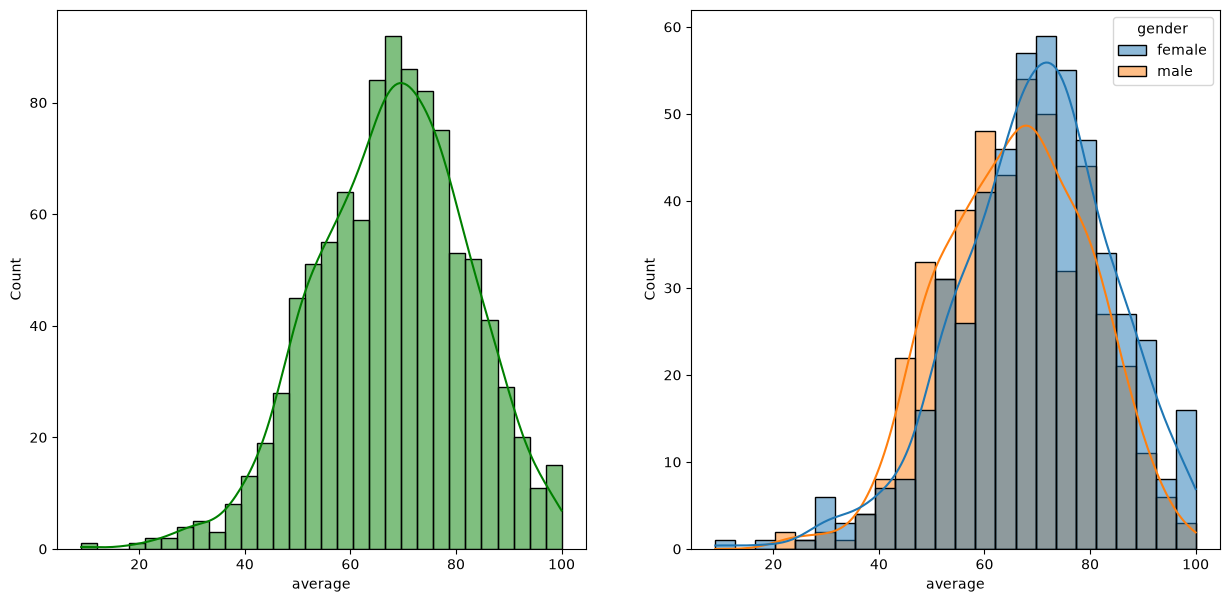

In [17]:
fig, axs = plt.subplots(1, 2, figsize = (15, 7))
plt.subplot(121)
sns.histplot(data = df, x = 'average', bins = 30, kde = True, color = 'g')
plt.subplot(122)
sns.histplot(data = df, x = 'average', kde = True, hue = 'gender')

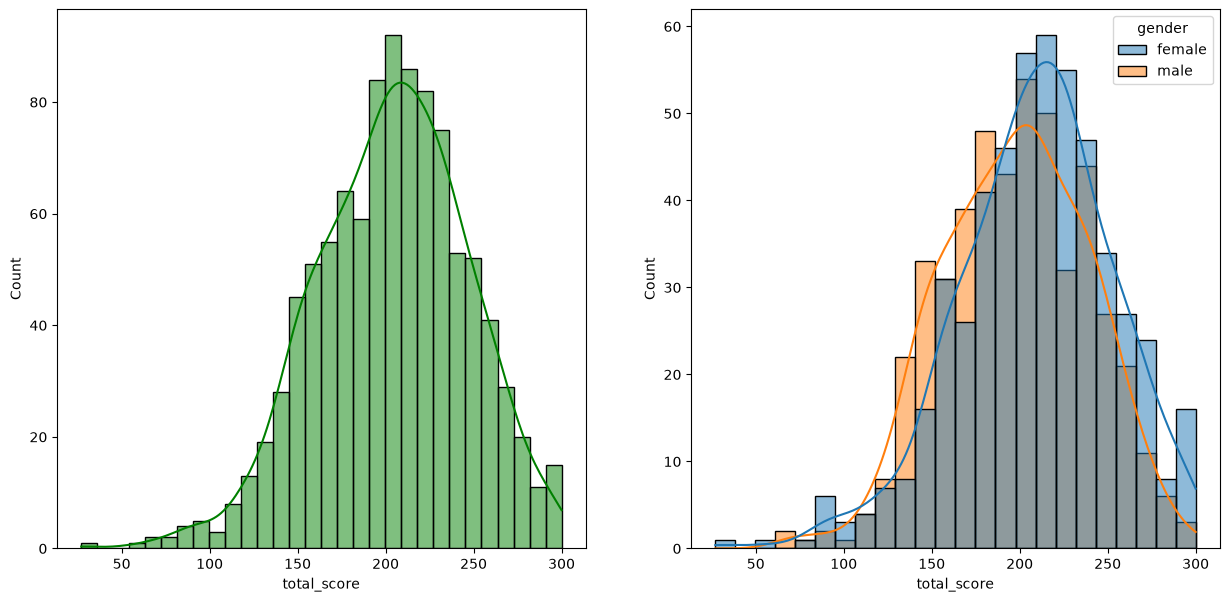

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x='total_score', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='total_score', kde=True, hue='gender')
plt.show()

##### Insights
- Female students tend to perform well then male students.

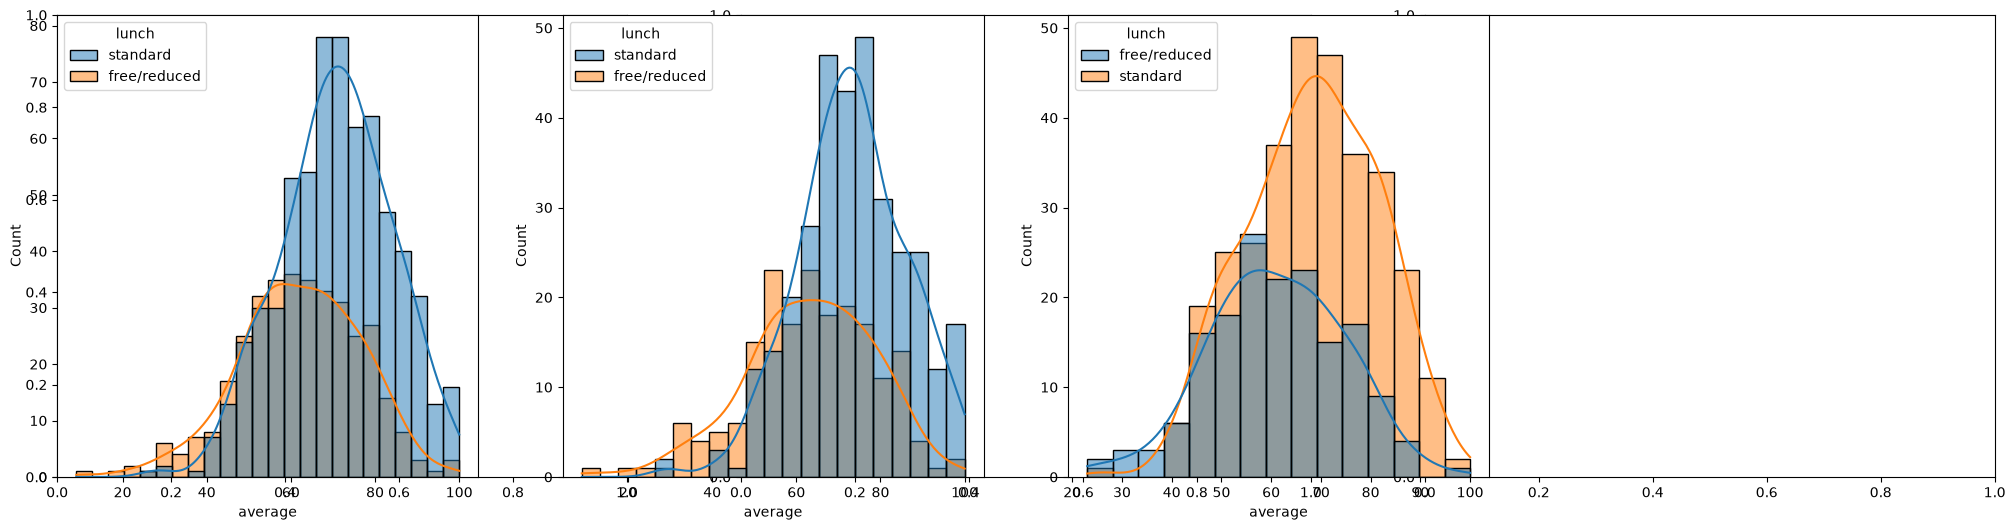

In [19]:
fig, axs = plt.subplots(1, 3, figsize = (25, 6))
plt.subplot(141)
sns.histplot(data = df, x = 'average', kde = True, hue = 'lunch')
plt.subplot(142)
sns.histplot(data = df[df.gender == 'female'], x = 'average', kde = True, hue = 'lunch')
plt.subplot(143)
sns.histplot(data = df[df.gender == 'male'], x = 'average', kde = True, hue = 'lunch')
plt.show()

##### Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform will in exams for both male or female.

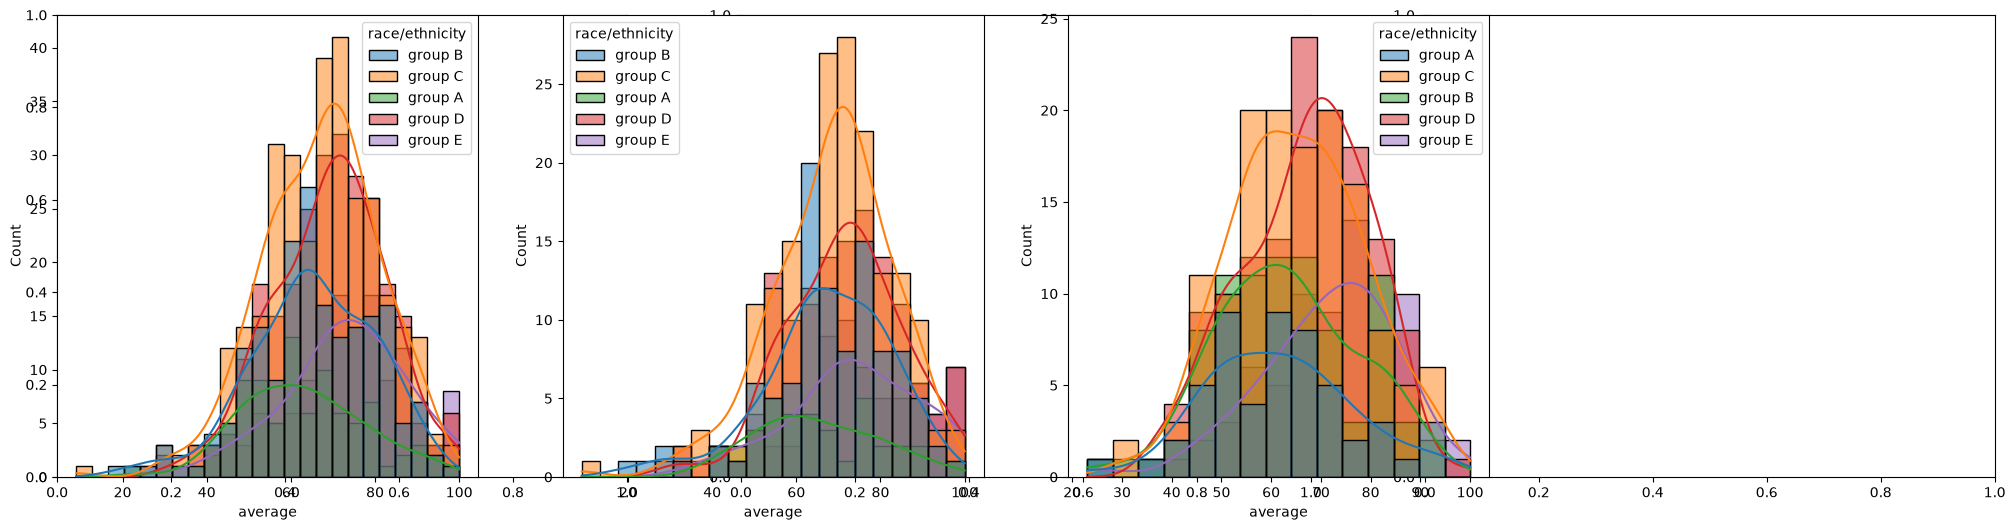

In [20]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average',kde=True,hue='race/ethnicity')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race/ethnicity')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race/ethnicity')
plt.show()


### Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

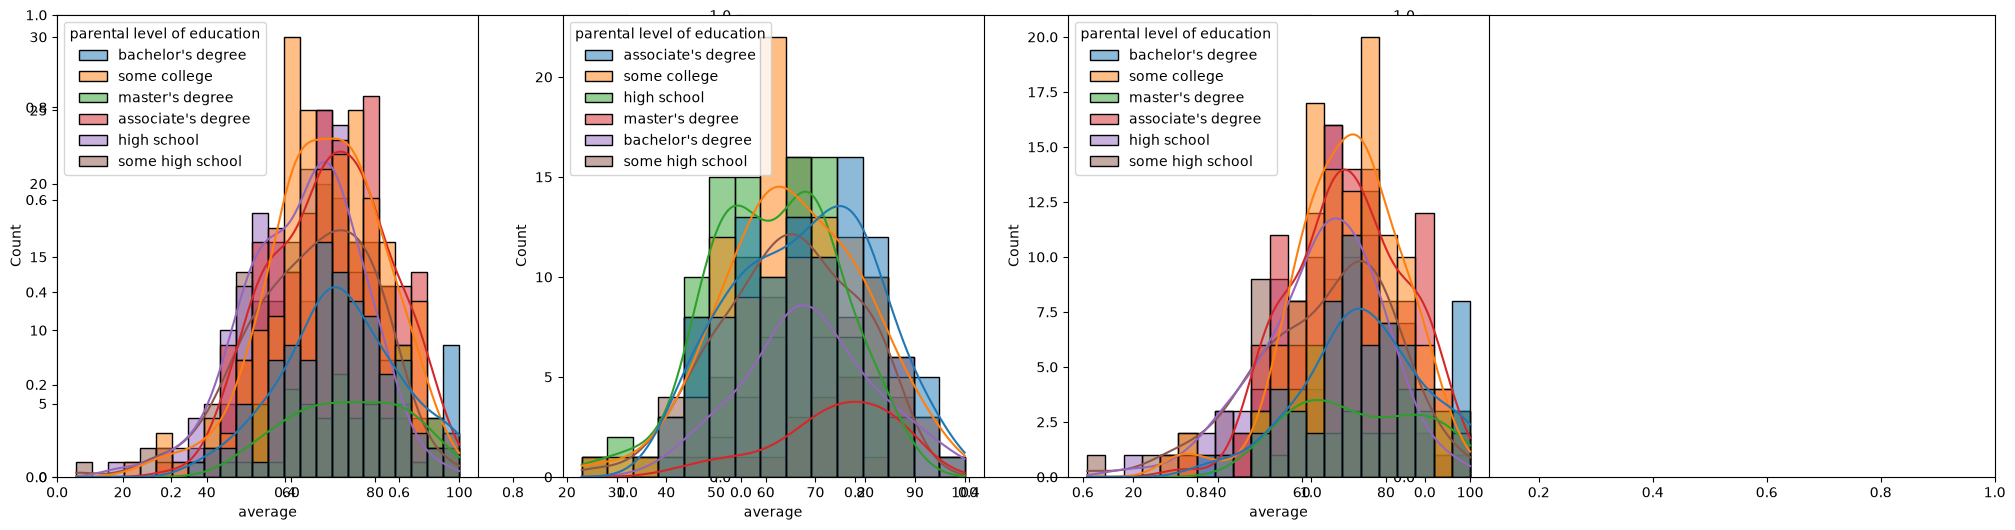

In [21]:

plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average',kde=True,hue='parental level of education')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental level of education')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental level of education')
plt.show()

### Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

### 4.2 Maximum score of students in all three subjects.

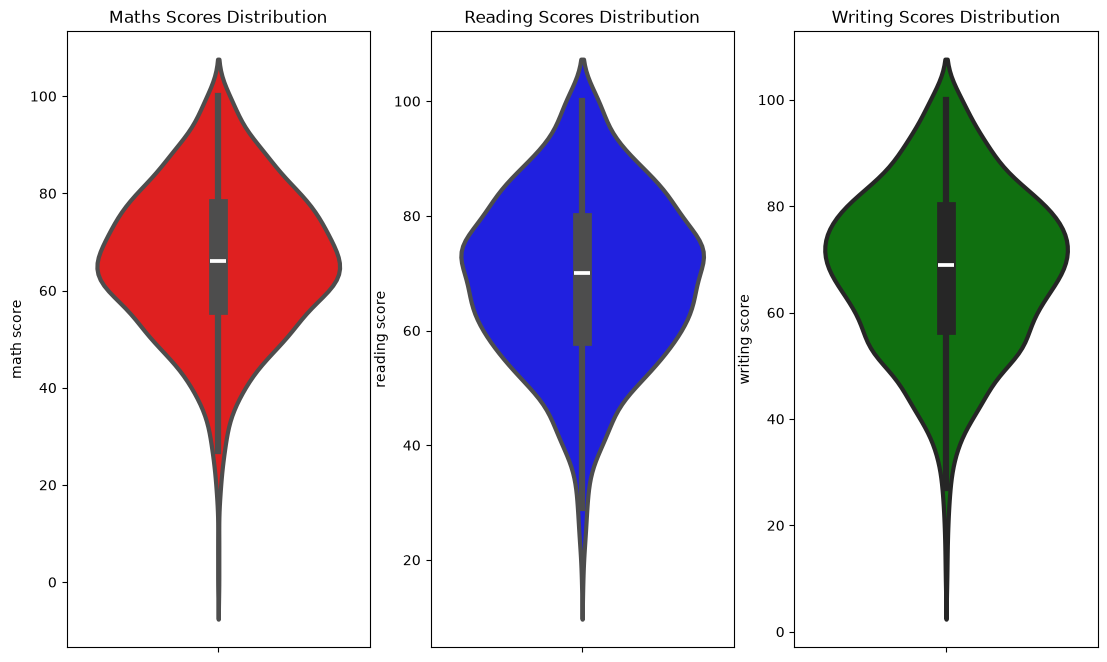

In [98]:
plt.figure(figsize = (18, 8))
plt.subplot(1, 4, 1)
plt.title('Maths Scores Distribution')
sns.violinplot(y = 'math score', data = df, color = 'red', linewidth = 3)
plt.subplot(1, 4, 2)
plt.title('Reading Scores Distribution')
sns.violinplot(y = 'reading score', data = df, color = 'blue', linewidth = 3)
plt.subplot(1, 4, 3)
plt.title('Writing Scores Distribution')
sns.violinplot(y = 'writing score', data = df, color = 'green', linewidth = 3)
plt.show()

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

### 4.3 Multivariate analysis using pieplot

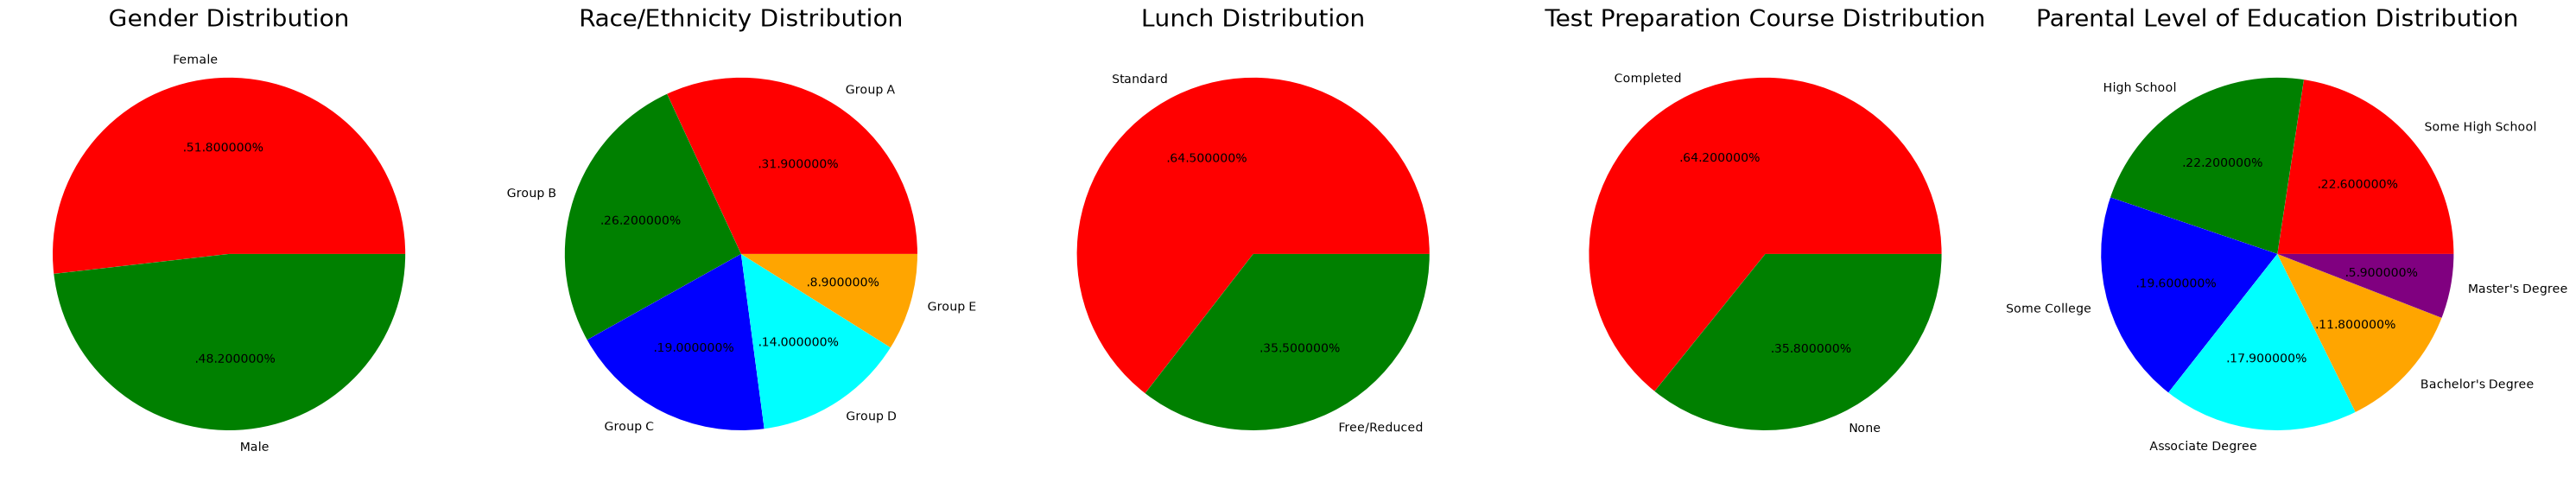

In [101]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = ['Female', 'Male']
color = ['red', 'green']

plt.pie(size, colors = color, labels = labels, autopct = '.%2f%%')
plt.title('Gender Distribution', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 2)
size = df['race/ethnicity'].value_counts()
labels = ['Group A', 'Group B', 'Group C', 'Group D', 'Group E']
color = ['red', 'green', 'blue', 'cyan', 'orange']

plt.pie(size, colors = color, labels = labels, autopct = '.%2f%%')
plt.title('Race/Ethnicity Distribution', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = ['Standard', 'Free/Reduced']
color = ['red', 'green']

plt.pie(size, colors = color, labels = labels, autopct = '.%2f%%')
plt.title('Lunch Distribution', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 4)
size = df['test preparation course'].value_counts()
labels = ['Completed', 'None']
color = ['red', 'green']

plt.pie(size, colors = color, labels = labels, autopct = '.%2f%%')
plt.title('Test Preparation Course Distribution', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
labels = ['Some High School', 'High School', 'Some College', 'Associate Degree', "Bachelor's Degree", "Master's Degree"]
color = ['red', 'green', 'blue', 'cyan', 'orange', 'purple']

plt.pie(size, colors = color, labels = labels, autopct = '.%2f%%')
plt.title('Parental Level of Education Distribution', fontsize = 20)
plt.axis('off')

plt.tight_layout()
plt.grid()

plt.show()

### Insights
- Number of Male and Female students is almost equal.
- Number students are greatest in Group C.
- Number of students who have standard lunch are greater.
- Number of students who have not enrolled in any test preparation course is greater.
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree".

## 4.4 Feature Wise Visualization

### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

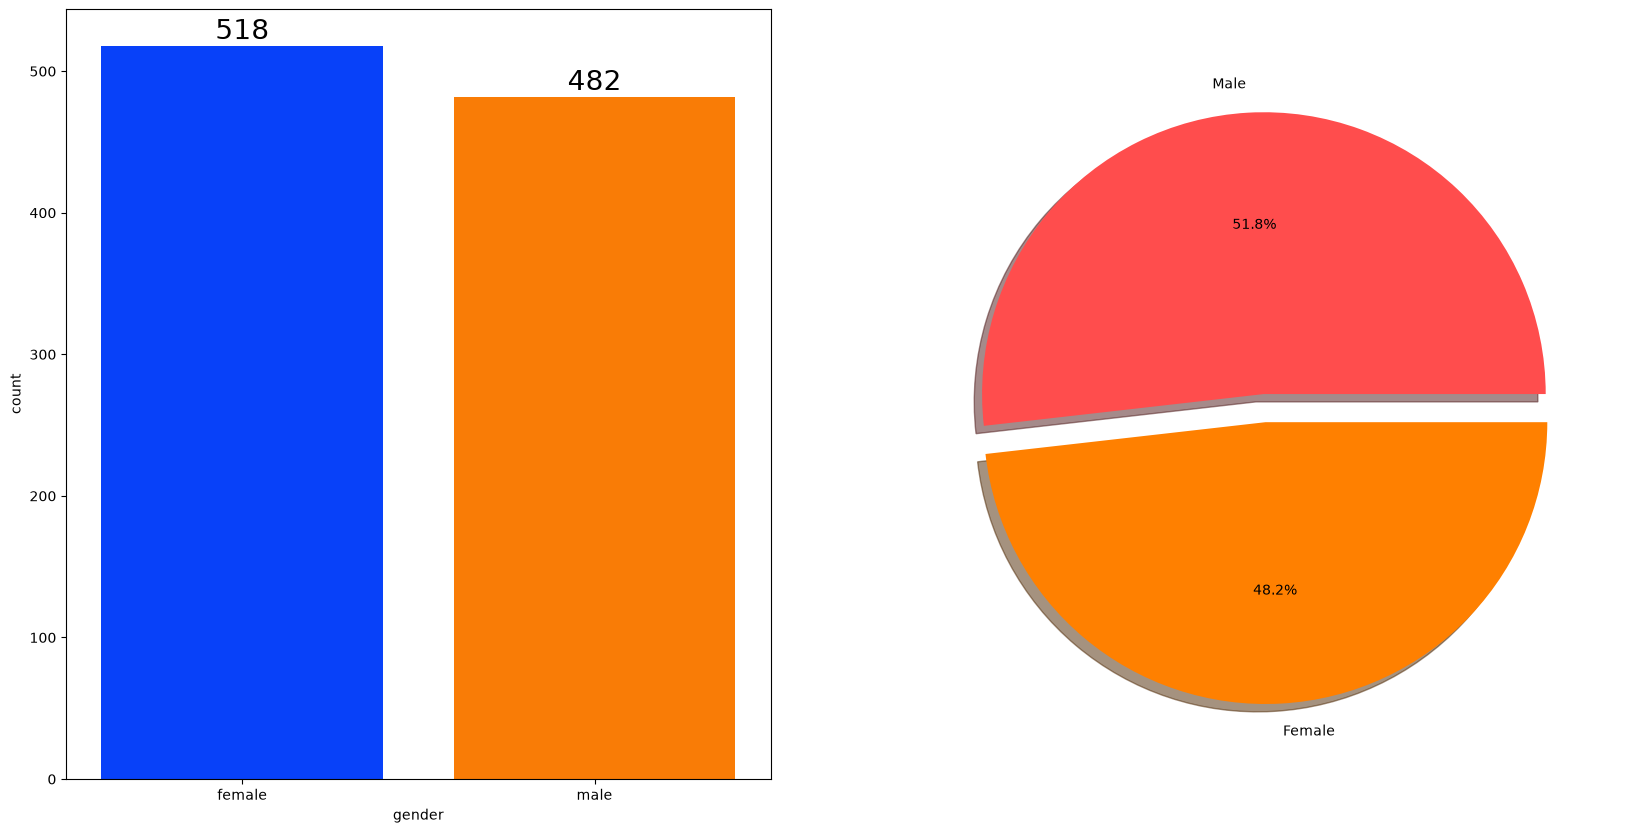

In [103]:
fig, axs = plt.subplots(1, 2, figsize = (20, 10))
sns.countplot(x = df['gender'], data = df, palette = 'bright', ax = axs[0], saturation = 0.95)
for container in axs[0].containers:
    axs[0].bar_label(container, color = 'black', size = 20)

plt.pie(x = df['gender'].value_counts(), labels = ['Male', 'Female'], explode = [0, 0.1], autopct = '%1.1f%%', shadow = True, colors = ['#ff4d4d', '#ff8000'])
plt.show()

### Insights
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [105]:
gender_group = df.groupby('gender').mean(numeric_only=True)
print(gender_group)

        math score  reading score  writing score  total_score    average
gender                                                                  
female   63.633205      72.608108      72.467181   208.708494  69.569498
male     68.728216      65.473029      63.311203   197.512448  65.837483


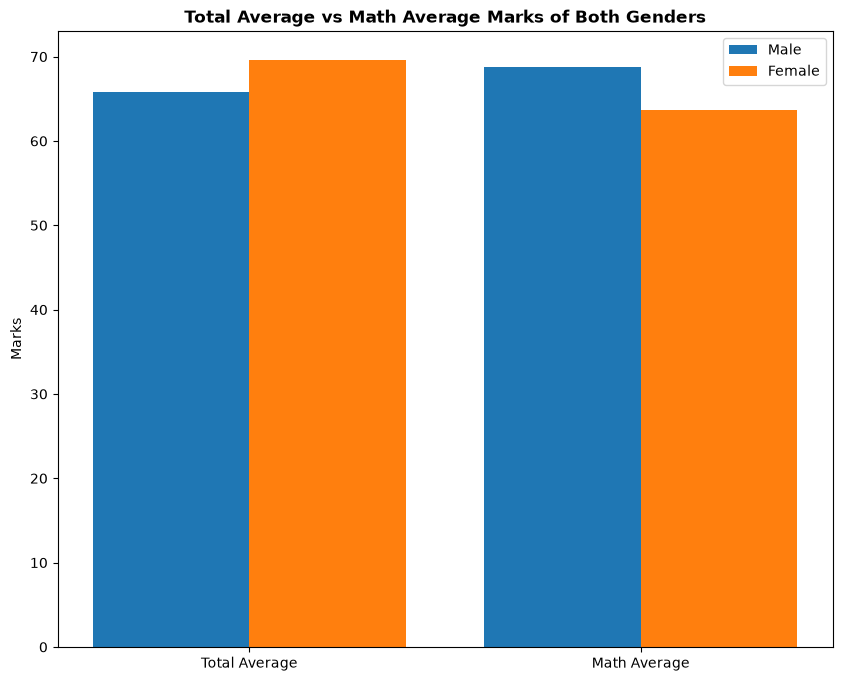

In [107]:
plt.figure(figsize=(10, 8))

X = ['Total Average', 'Math Average']

female_scores = [
    gender_group.loc['female', 'average'],
    gender_group.loc['female', 'math score']
]

male_scores = [
    gender_group.loc['male', 'average'],
    gender_group.loc['male', 'math score']
]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total Average vs Math Average Marks of Both Genders", fontweight='bold')
plt.legend()
plt.show()

### Insights
- On an average females have a better overall score than men.
whereas males have scored higher in Maths.

### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

##### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

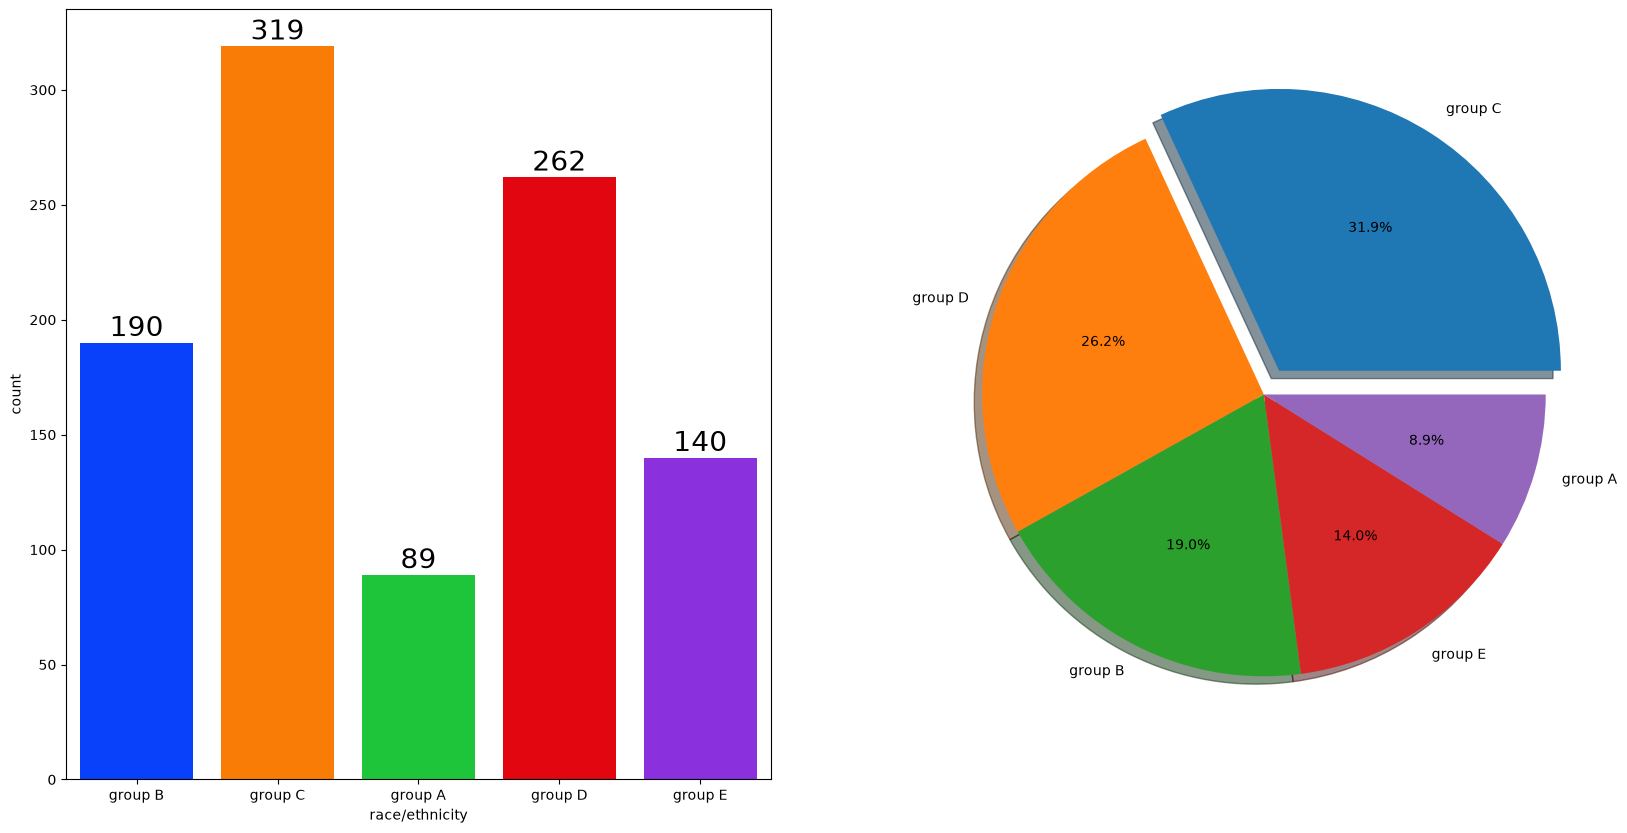

In [112]:
fig, axs = plt.subplots(1, 2, figsize = (20, 10))
sns.countplot(x = df['race/ethnicity'], data = df, palette = 'bright', ax = axs[0], saturation = 0.95)
for container in axs[0].containers:
    axs[0].bar_label(container, color = 'black', size = 20)

plt.pie(x = df['race/ethnicity'].value_counts(), labels=df['race/ethnicity'].value_counts().index, explode = [0.1, 0, 0, 0, 0], autopct = '%1.1f%%', shadow = True)
plt.show()

#### Insights
Most of the student belonging from group C /group D.
Lowest number of students belong to groupA

### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

In [114]:
gender_group2 = df.groupby('race/ethnicity').mean(numeric_only=True)
print(gender_group2)

                math score  reading score  writing score  total_score  \
race/ethnicity                                                          
group A          61.629213      64.674157      62.674157   188.977528   
group B          63.452632      67.352632      65.600000   196.405263   
group C          64.463950      69.103448      67.827586   201.394984   
group D          67.362595      70.030534      70.145038   207.538168   
group E          73.821429      73.028571      71.407143   218.257143   

                  average  
race/ethnicity             
group A         62.992509  
group B         65.468421  
group C         67.131661  
group D         69.179389  
group E         72.752381  


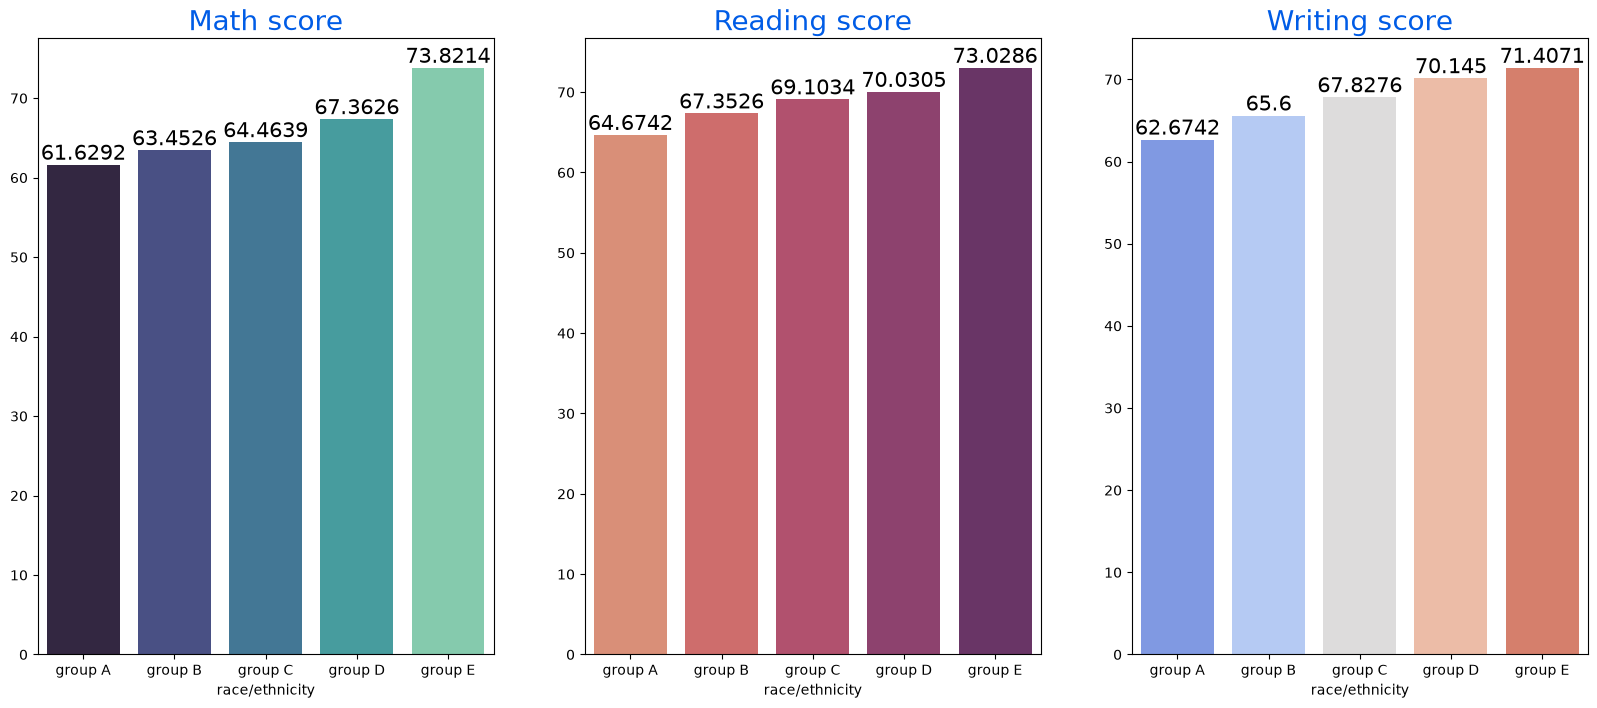

In [118]:

Group_data2 = df.groupby('race/ethnicity')
f, ax = plt.subplots(1, 3, figsize = (20,8))
sns.barplot(x = Group_data2['math score'].mean().index, y = Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)


### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

findfont: Failed to find font weight 30, now using 200.


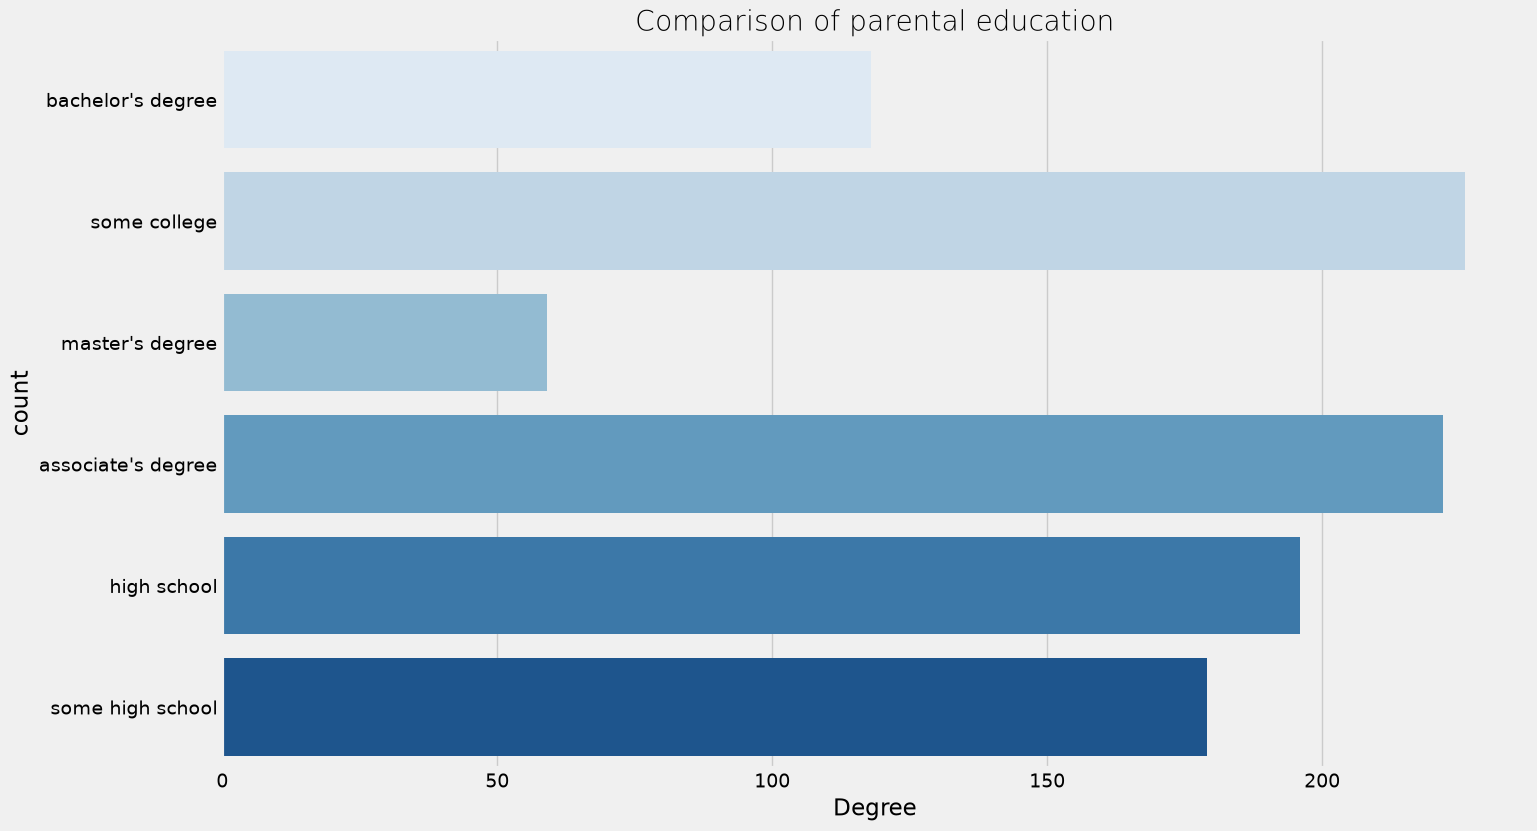

In [120]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'], palette = 'Blues')
plt.title('Comparison of parental education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

##### Insights
- Largest number of parents are from some college.


### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? 

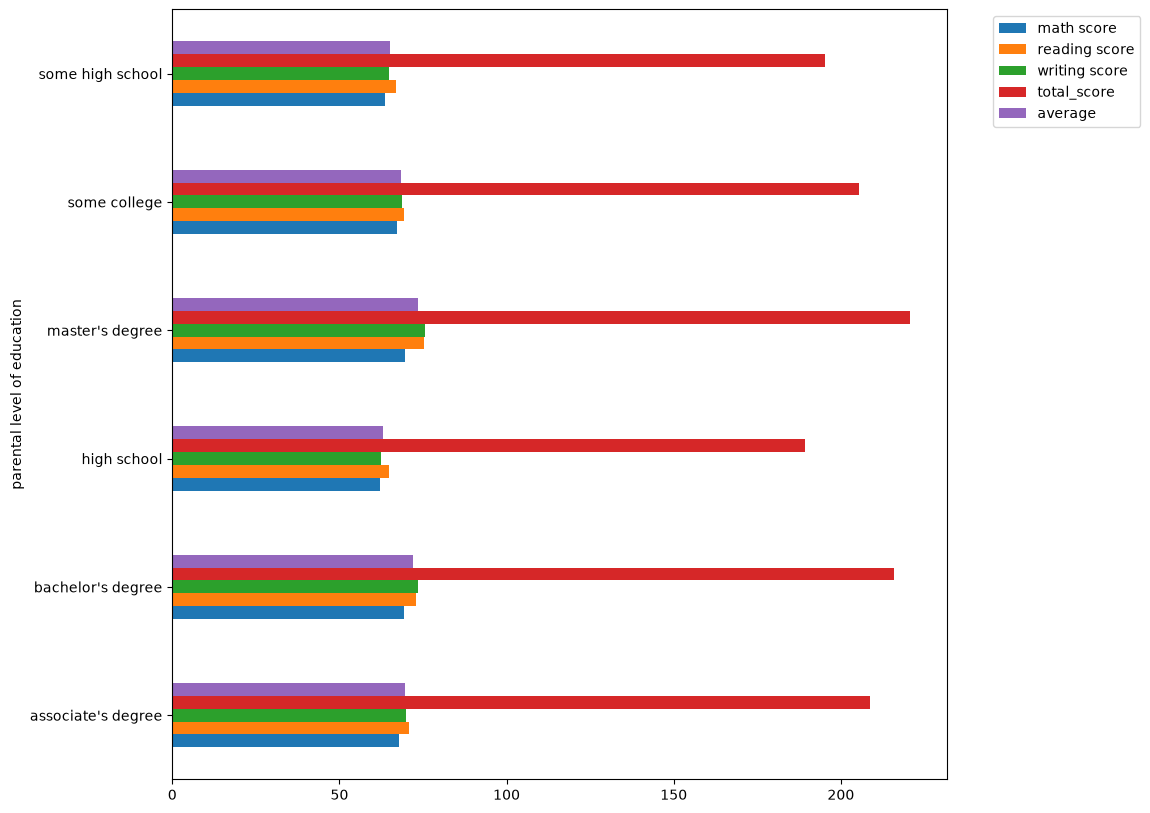

In [22]:
(
    df.groupby('parental level of education')
      .mean(numeric_only=True)
      .plot(kind='barh', figsize=(10, 10))
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Insights
- The score of student whose parents possess master and bachelor level education are higher than others

## 4.4.4 LUNCH COLUMN
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?

### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

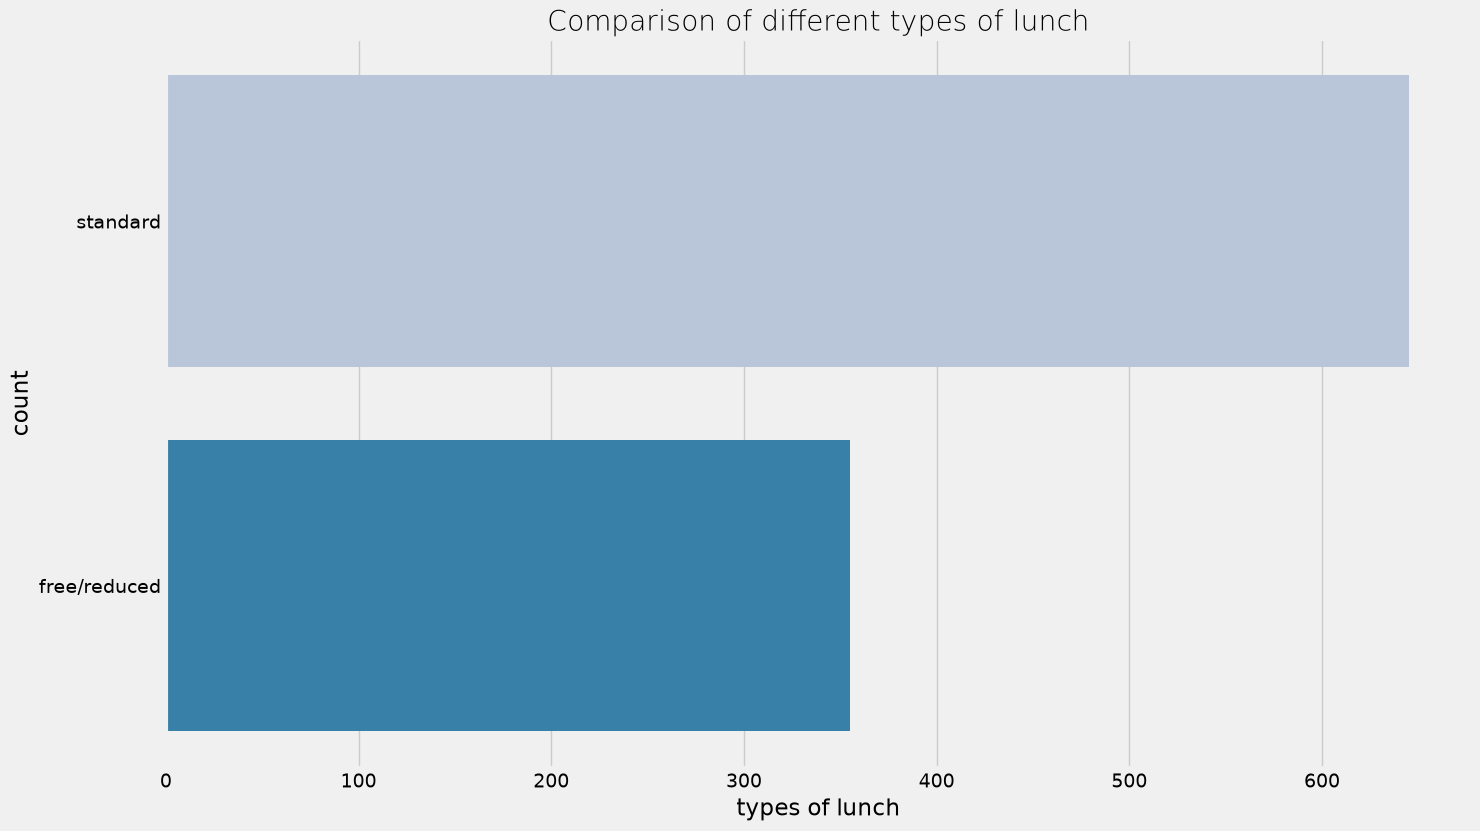

In [127]:

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

### Insights
- Students being served Standard lunch was more than free lunch

### BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

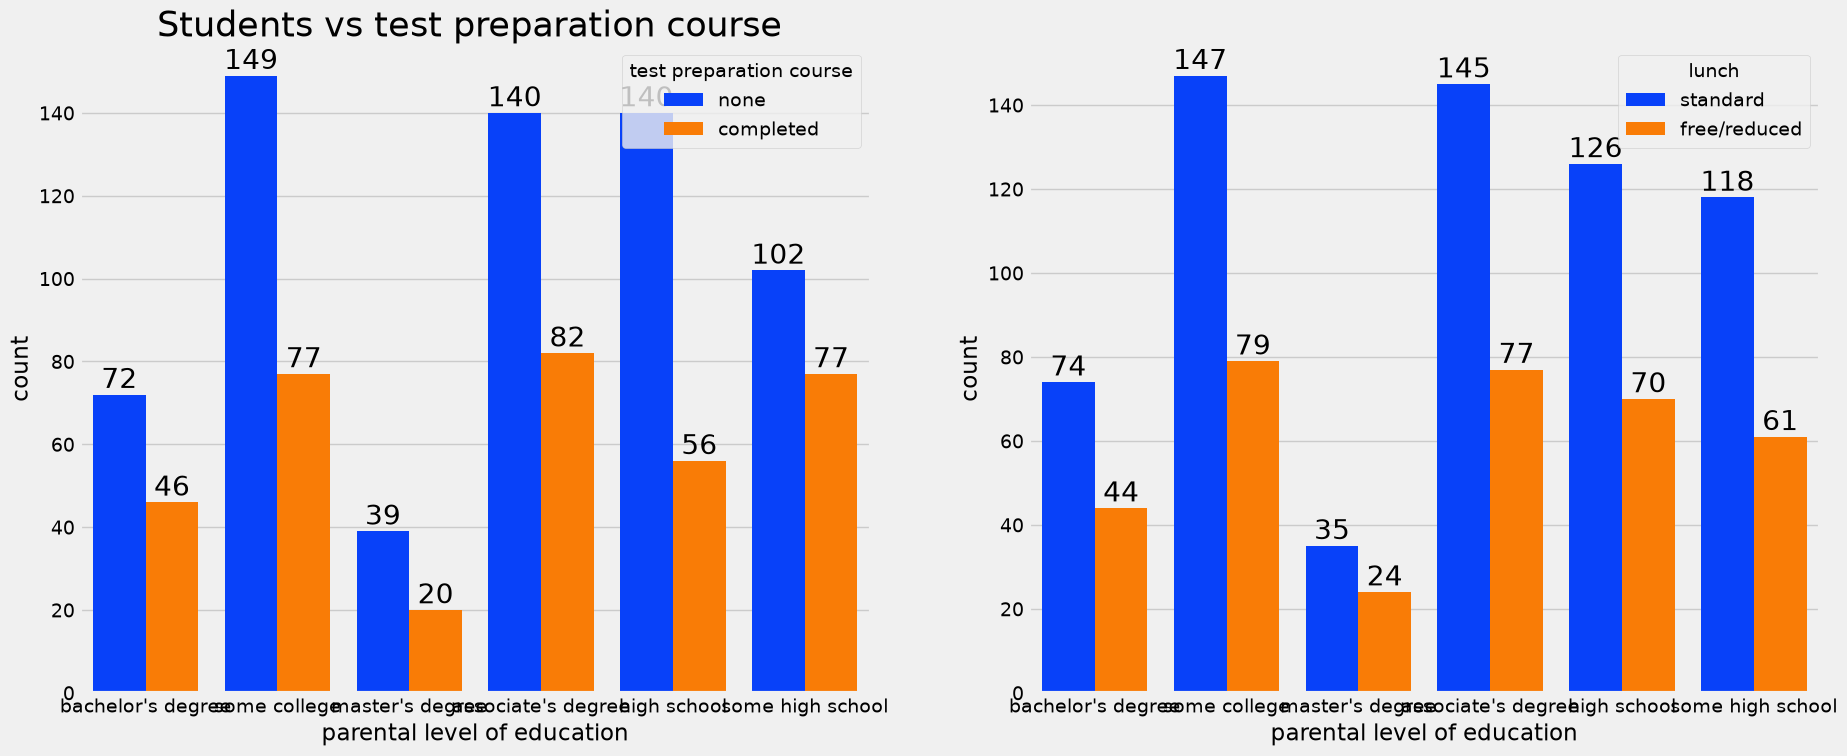

In [128]:

f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='test preparation course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20) 

### 4.4.5 TEST PREPARATION COURSE COLUMN
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='writing score'>

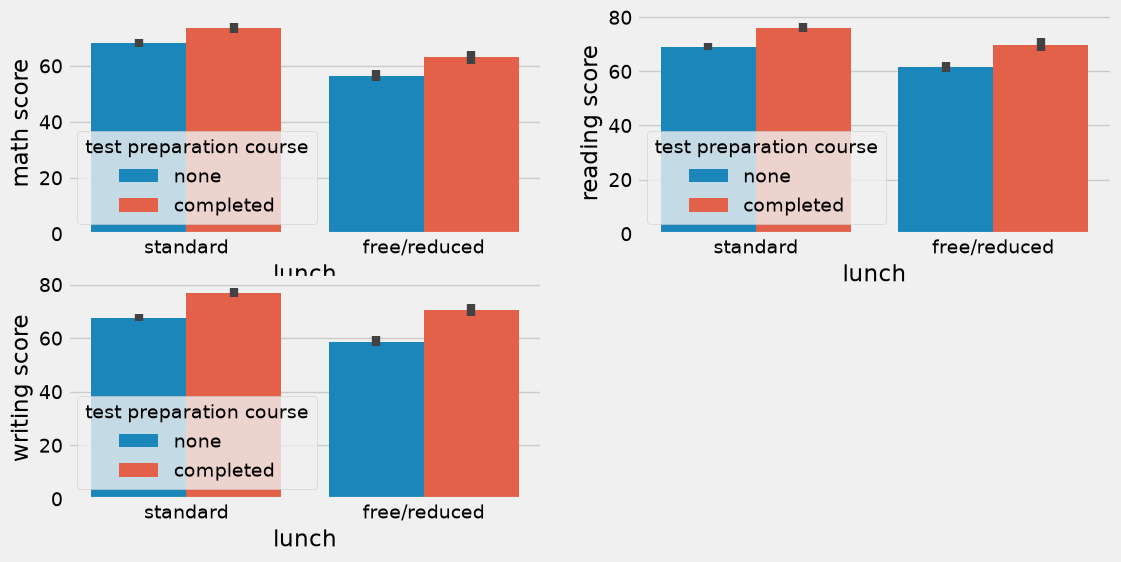

In [129]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math score'], hue=df['test preparation course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading score'], hue=df['test preparation course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing score'], hue=df['test preparation course'])

### Insights
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

### 4.4.6 CHECKING OUTLIERS

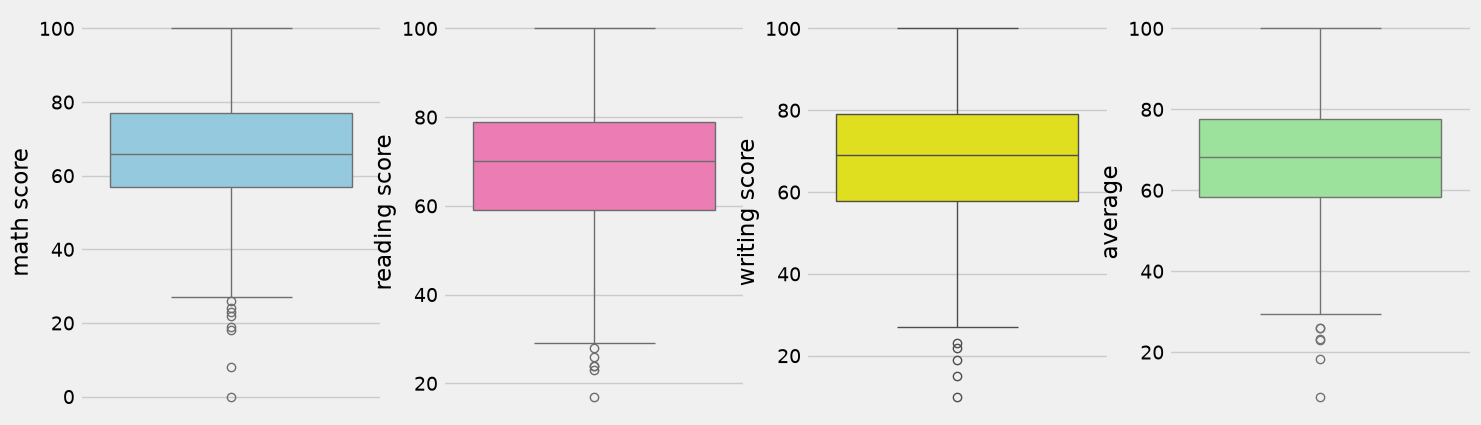

In [130]:
plt.subplots(1, 4, figsize = (16, 5))
plt.subplot(141)
sns.boxplot(df['math score'], color = 'skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'], color = 'hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'], color = 'yellow')
plt.subplot(144)
sns.boxplot(df['average'], color = 'lightgreen')
plt.show()

4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

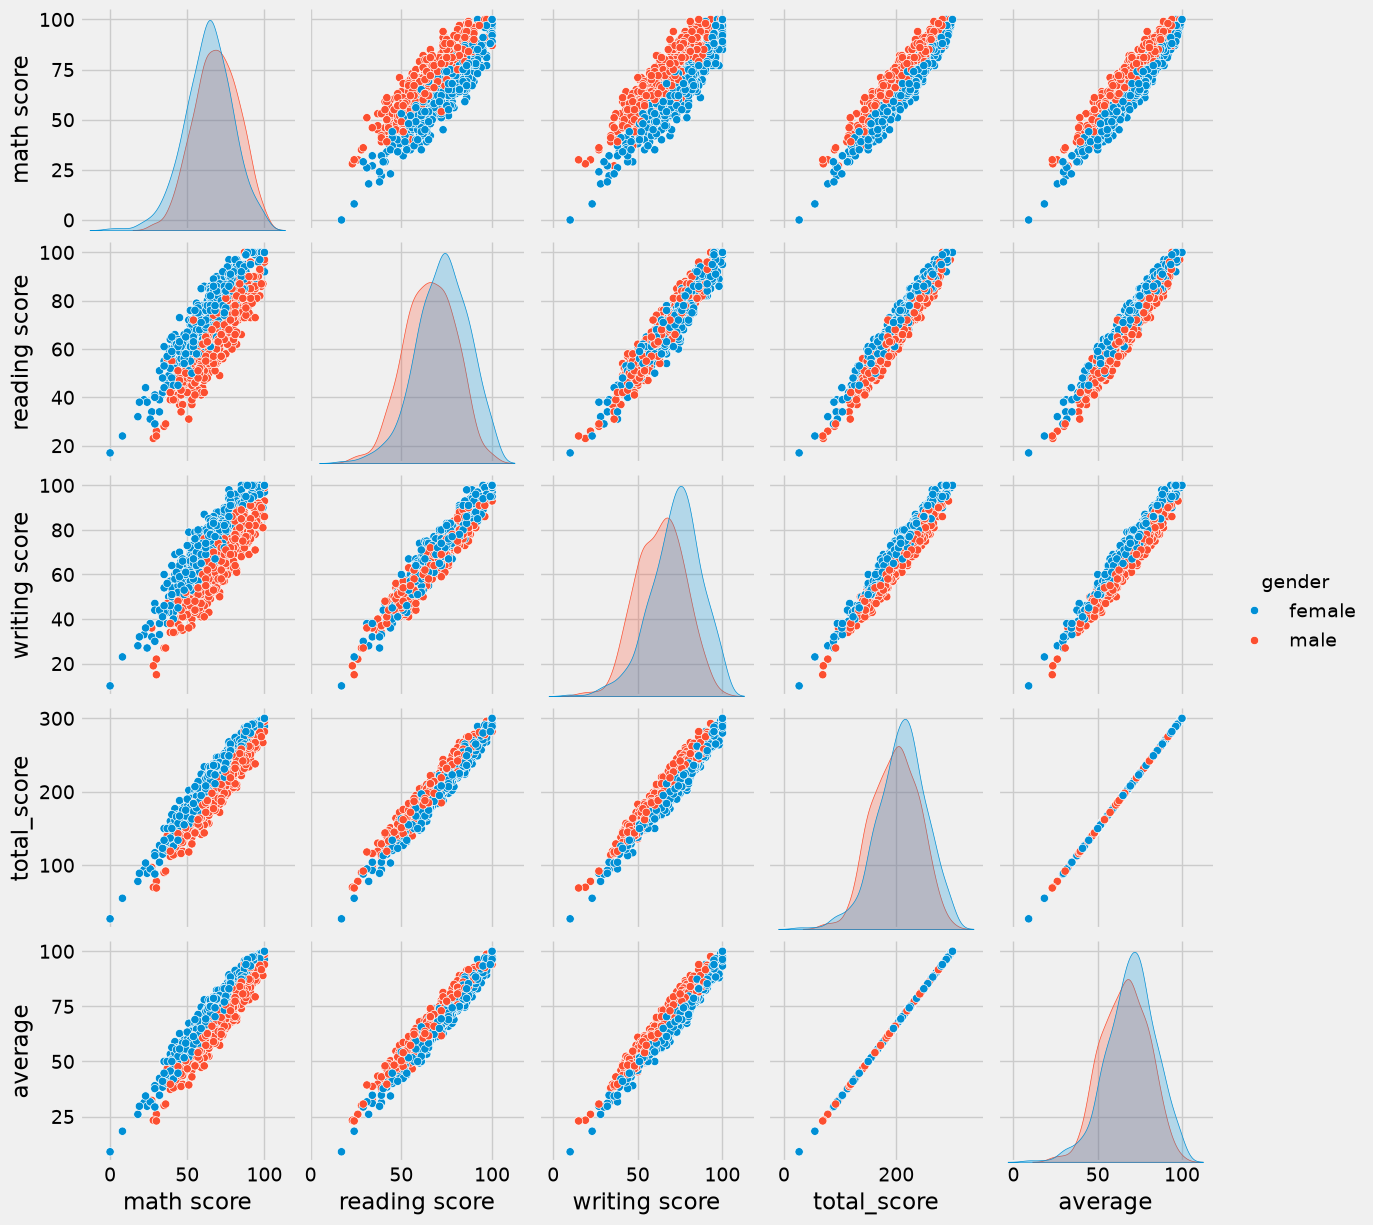

In [131]:
sns.pairplot(df, hue = 'gender')
plt.show()

### Insights
- From the above plot it is clear that all the scores increase linearly with each other

## 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.